
# <span style="color:green">📊📣 Ejercicio Preparación de Datos. Elección del método anticonceptivo</span>

Grupo Nro 4:
*   Leimar Torres
*   Oscar Montaño
*   Juan Hurtado


##I. Cargar el conjunto de datos en un data frame de pandas:

Los datos son tomados desde el siguiente link https://archive.ics.uci.edu/dataset/30/contraceptive+method+choice



In [1]:
!pip install ucimlrepo

In [2]:
#Cargamos las librerias necesarias

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
dataset = fetch_ucirepo(id=30)

# Features y target tal como vienen
X = dataset.data.features
y = dataset.data.targets

X.head()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure
0,24,2,3,3,1,1,2,3,0
1,45,1,3,10,1,1,3,4,0
2,43,2,3,7,1,1,3,4,0
3,42,3,2,9,1,1,3,3,0
4,36,3,3,8,1,1,3,2,0


In [3]:
y.head()

,contraceptive_method
0,1
1,1
2,1
3,1
4,1


##II. Información del dataset y las variables

In [4]:
# metadatos
print(dataset.metadata)

{'uci_id': 30, 'name': 'Contraceptive Method Choice', 'repository_url': 'https://archive.ics.uci.edu/dataset/30/contraceptive+method+choice', 'data_url': 'https://archive.ics.uci.edu/static/public/30/data.csv', 'abstract': 'Dataset is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1473, 'num_features': 9, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Education Level', 'Other', 'Occupation'], 'target_col': ['contraceptive_method'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C59W2D', 'creators': ['Tjen-Sien Lim'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey. The samples are married women who were either

In [5]:
#variables
print(dataset.variables)

                       name     role         type      demographic  \
0                  wife_age  Feature      Integer              Age   
1                  wife_edu  Feature  Categorical  Education Level   
2               husband_edu  Feature  Categorical  Education Level   
3              num_children  Feature      Integer            Other   
4             wife_religion  Feature       Binary            Other   
5              wife_working  Feature       Binary       Occupation   
6        husband_occupation  Feature  Categorical       Occupation   
7  standard_of_living_index  Feature  Categorical             None   
8            media_exposure  Feature       Binary             None   
9      contraceptive_method   Target  Categorical             None   

  description units missing_values  
0        None  None             no  
1        None  None             no  
2        None  None             no  
3        None  None             no  
4        None  None             no  
5      

Este conjunto de datos es un subconjunto de la Encuesta Nacional de Prevalencia de Anticonceptivos de Indonesia de 1987. Las muestras son mujeres casadas que no estaban embarazadas o que desconocen si lo estaban en el momento de la entrevista. El problema consiste en predecir la elección actual de un método anticonceptivo (no uso, métodos a largo plazo o métodos a corto plazo) por parte de una mujer en función de sus características demográficas y socioeconómicas. El dataset esta compuesto por 1473 registros,  9 características predictoras y 1 variable objetivo, utilizada para clasificar el metodo.

Las variables incluidas en el dataset son las siguientes:

*   wife_age: edad de la esposa
*   wife_edu: nivel estudio de la esposa (Categórica Ordinal, 1 = baja, 2, 3, 4 = alta)
*   husband_edu: nivel de estudio del esposo (Categórica Ordinal, 1 = baja, 2, 3, 4 = alta)
*   num_children: numero de hijos nacidos
*   wife_religion: religion de la esposa (binaria 0 = No islámica, 1 = islam)
*   wife_working: Trabaja actualmente la esposa (binaria 0 = Sí, 1 = No)
*   husband_occupation: Ocupación del esposo (Categórica 1, 2, 3, 4).
*   standard_of_living_index: Indice del nivel de vida (categórico Ordinal 1 = baja, 2, 3, 4=alta).
*   media_exposure: Exposición de los medios (binaria, 0 = Buena, 1 = Mala)
*   contraceptive_method: Método anticonceptivo utilizado (Categórica, atributo de clase 1 = No uso, 2 = Largo plazo, 3 = Corto plazo).


## III. Construcción de los casos


Dado que las características y la variable objetivo se encuentran en estructuras separadas, procedemos a unificarlas en un único dataset con el fin de consolidar toda la información en un mismo objeto y facilitar su análisis.

In [6]:
# Convertir y a Serie 1D (tomando la única columna)
y = y.iloc[:, 0]

#  Unir en un solo DataFrame
df = X.copy()
df['metodo'] = y

df.head()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,metodo
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


In [7]:
df.shape

(1473, 10)

### 1. Conjunto original (Transformando datos categóricos, si aplica)

Para ello validemos el tipo de datos de las variables:

In [8]:
#Cual es el tipo de los atributos?
df.dtypes

,0
wife_age,int64
wife_edu,int64
husband_edu,int64
num_children,int64
wife_religion,int64
wife_working,int64
husband_occupation,int64
standard_of_living_index,int64
media_exposure,int64
metodo,int64


Evidenciamos que todas las variables estan en formato integer, por lo que debemos transformarlas en categoricas las variables relacionadas a nivel de educación, ocupación y nivel de vida. Por otro lado, transformar a binarias las variables de religión, trabajo de la esposa y exposición a los medios.

In [9]:
# 1. Transformación Variables ordinales (categóricas con orden):


ordinal_vars = ["wife_edu", "husband_edu", "standard_of_living_index"]

for col in ordinal_vars:
    df[col] = df[col].astype("category")

In [10]:
#2. Transformación Variables nominales (categóricas sin orden)

nominal_vars = ["husband_occupation"]

for col in nominal_vars:
    df[col] = df[col].astype("category")

In [11]:
# 3. Tranformación variables binarias

binary_vars = ["wife_religion", "wife_working", "media_exposure"]

for col in binary_vars:
    df[col] = df[col].astype("category")

In [12]:
#Con las transformaciones realizadas, validamos que los formatos hayan quedado correctos:

df.dtypes

,0
wife_age,int64
wife_edu,category
husband_edu,category
num_children,int64
wife_religion,category
wife_working,category
husband_occupation,category
standard_of_living_index,category
media_exposure,category
metodo,int64


La variable metodo corresponde a la variable objetivo del problema de clasificación. Aunque conceptualmente es una variable categórica nominal (1 = No uso, 2 = Uso de métodos a largo plazo, 3 = Uso de métodos a corto plazo), no se transforma a formato categórico ni se generan variables dummy, ya que los algoritmos de clasificación de Scikit-learn trabajan directamente con etiquetas enteras sin necesidad de recodificación adicional.

### 2. Conjunto sin datos faltantes



In [13]:
#Cuantos datos faltantes hay por cada atributo?
df.isnull().sum()

,0
wife_age,0
wife_edu,0
husband_edu,0
num_children,0
wife_religion,0
wife_working,0
husband_occupation,0
standard_of_living_index,0
media_exposure,0
metodo,0


En ests caso no presentamos datos faltantes

### 3. Conjunto sin datos faltantes ni atípicos

Para las variables numericas utlicemos el comando describe para validar la distribución de los datos, adicional de Boxplot.

In [14]:
df.describe()

,wife_age,num_children,metodo
count,1473.000000,1473.000000,1473.000000
mean,32.538357,3.261371,1.919891
std,8.227245,2.358549,0.876376
min,16.000000,0.000000,1.000000
25%,26.000000,1.000000,1.000000
50%,32.000000,3.000000,2.000000
75%,39.000000,4.000000,3.000000
max,49.000000,16.000000,3.000000


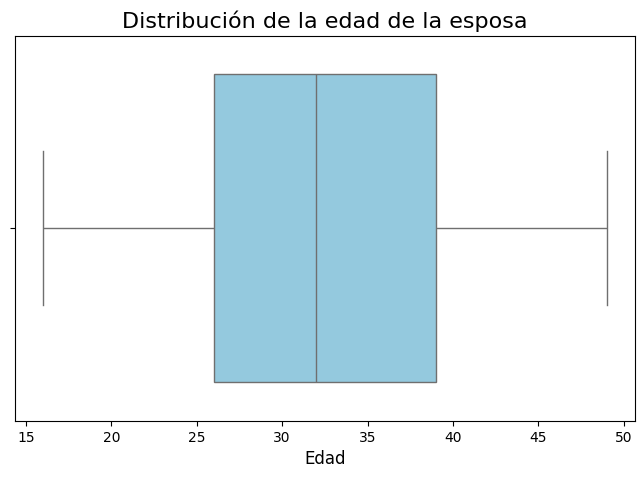

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['wife_age'], color='skyblue')   # Color del boxplot

plt.title("Distribución de la edad de la esposa", fontsize=16)
plt.xlabel("Edad", fontsize=12)

plt.show()

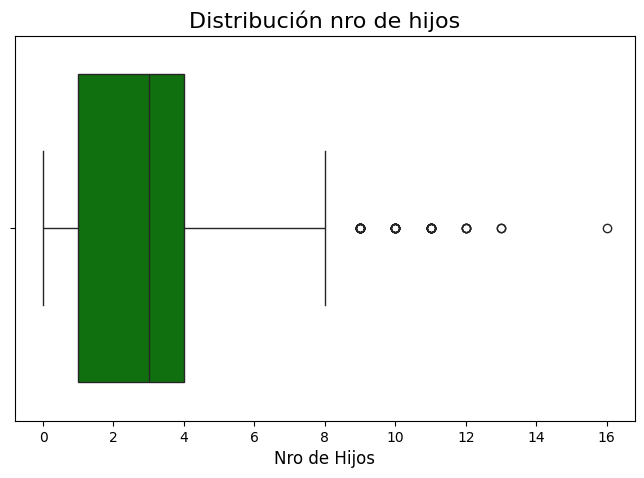

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['num_children'], color='green')   # Color del boxplot

plt.title("Distribución nro de hijos", fontsize=16)
plt.xlabel("Nro de Hijos", fontsize=12)

plt.show()

Se observa que la edad mínima registrada para la esposa es de 16 años y la máxima de 49 años. Estos valores se encuentran dentro del rango esperado para la población en edad fértil, por lo que no se evidencian valores atípicos desde una perspectiva demográfica y estadística. En consecuencia, no es necesario realizar ajustes o depuraciones adicionales para esta variable.

Para la variable número de hijos, se observan valores por encima del rango intercuartílico, especialmente en mujeres con más de 8 hijos. Aunque estos pueden considerarse atípicos estadísticamente, son coherentes con el contexto del año 1987, cuando el acceso a información y métodos anticonceptivos era limitado. Por ello, estos valores se consideran válidos y representativos de la población.

Finalmente para el variable "método" no se evidencian atipicos ya que se encuentra en la escala de 1 a 3.

2. Para variables categoricas, utilicemos graficos de barras, esto sera útil para identificar frecuencias inconsistentes.

/tmp/ipython-input-2559048618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Pastel1")
/tmp/ipython-input-2559048618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Pastel1")
/tmp/ipython-input-2559048618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Pastel1")
/tmp/ipython-input-2559048618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

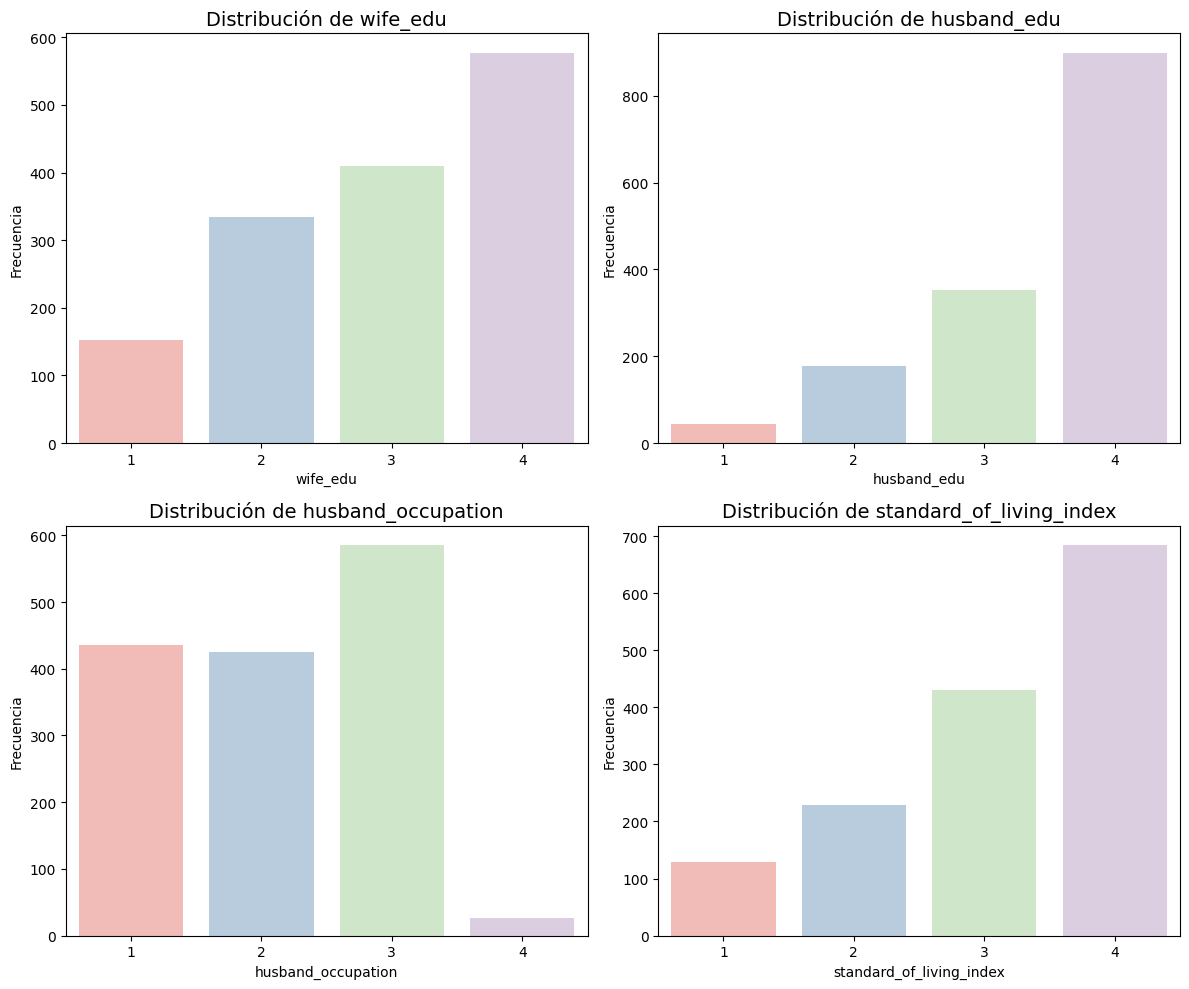

In [17]:
# Lista de variables
vars_cat = ["wife_edu", "husband_edu", "husband_occupation", "standard_of_living_index"]

# Crear figura
plt.figure(figsize=(12, 10))

# Recorrer variables y graficar
for i, col in enumerate(vars_cat, 1):
    plt.subplot(2, 2, i)  # Grid 2x2
    sns.countplot(x=df[col], palette="Pastel1")
    plt.title(f"Distribución de {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

para este caso, evidenciamos frecuencias en los rangos establecidos (1 al 4)


3. Repliquemos el mismo ejercicio para las variables binarias

/tmp/ipython-input-2621919324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
/tmp/ipython-input-2621919324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
/tmp/ipython-input-2621919324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


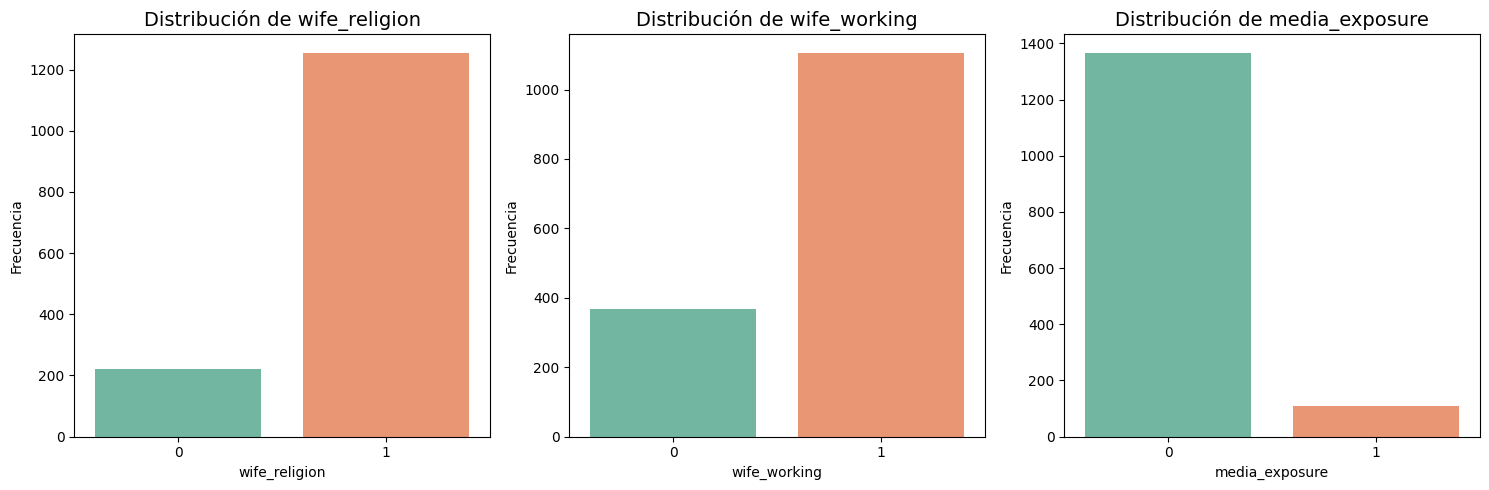

In [18]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(binary_vars, 1):
    plt.subplot(1, 3, i)  # Grid de 1x3
    sns.countplot(x=df[col], palette="Set2")
    plt.title(f"Distribución de {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Tampoco evidenciamos frecuencias inconsistentes para las variables binarias, en este caso podemos concluir que no tenemos valores atípicos

### 4. Conjunto sin datos faltantes, ni atípicos, ni correlacionados


En este caso dado que utilizaremos correlación de Pearson, realicemos el cálculo de correlaciones solo las variables numericas en este caso: wife_age, num_children.

In [19]:
df_num = df[["wife_age", "num_children"]]

corr = df_num.corr(method="pearson")
corr

,wife_age,num_children
wife_age,1.000000,0.540126
num_children,0.540126,1.000000


La correlación entre la edad de la esposa (wife_age) y el número de hijos (num_children) es de 0.54, lo que indica una relación positiva moderada: a mayor edad, tiende a observarse un mayor número de hijos.
Aunque la asociación es consistente con el comportamiento esperado en datos poblacionales, su magnitud no es lo suficientemente alta como para generar problemas de multicolinealidad. Por lo tanto, no se considera necesario aplicar técnicas de reducción de dimensionalidad ni excluir alguna de estas variables del análisis.



Probemos calcular las correlaciones entre variables categoricas, para ello utilizaremos la correlación de CRAMER.

In [20]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))



In [21]:
cat_vars = [
    "wife_edu",
    "husband_edu",
    "wife_religion",
    "wife_working",
    "husband_occupation",
    "standard_of_living_index",
    "media_exposure"
]


matriz_cramer = pd.DataFrame(
    np.zeros((len(cat_vars), len(cat_vars))),
    index=cat_vars,
    columns=cat_vars
)

# Llenar matriz
for col1 in cat_vars:
    for col2 in cat_vars:
        matriz_cramer.loc[col1, col2] = cramers_v(df[col1], df[col2])

matriz_cramer

,wife_edu,husband_edu,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure
wife_edu,1.000000,0.400544,0.238953,0.082203,0.263920,0.224849,0.404429
husband_edu,0.400544,1.000000,0.192222,0.031901,0.240164,0.216398,0.300622
wife_religion,0.238953,0.192222,0.997328,0.067639,0.120916,0.208569,0.056605
wife_working,0.082203,0.031901,0.067639,0.998192,0.066009,0.088316,0.000000
husband_occupation,0.263920,0.240164,0.120916,0.066009,1.000000,0.183989,0.129363
standard_of_living_index,0.224849,0.216398,0.208569,0.088316,0.183989,1.000000,0.264045
media_exposure,0.404429,0.300622,0.056605,0.000000,0.129363,0.264045,0.995046


Las asociaciones entre las variables categóricas del conjunto de datos son en general débiles a moderadas. Las relaciones más destacadas se observan entre los niveles educativos de la pareja (wife_edu ↔ husband_edu) y entre educación y exposición a medios (wife_edu ↔ media_exposure), con valores cercanos a 0.40.
El resto de las asociaciones se encuentran por debajo de 0.30, lo que indica relaciones débiles. La variable wife_working presenta las asociaciones más bajas, sin dependencia clara con educación, religión, ocupación o nivel de vida.
En conjunto, no se observa ninguna asociación alta (Cramer’s V > 0.50) que sugiera redundancia fuerte entre variables. Por lo tanto, no es necesario aplicar técnicas de reducción de dimensionalidad para las variables categóricas, dado que no existe multicolinealidad significativa entre ellas.

**IMPORTANTE**: Hasta este punto se ha verificado que la base de datos no presenta valores faltantes, ni datos atípicos, ni correlaciones altas entre sus variables. Por lo tanto, la única transformación requerida corresponde a la recodificación de las variables categóricas a su formato adecuado. El resto de las variables se mantiene sin modificaciones, conservando la estructura original del conjunto de datos.

### 5. Conjunto balanceado y sin datos faltantes, ni atípicos, ni correlacionados


Evaluamos como vienen las categorias de método anticonceptivo:

In [22]:
df['metodo'].value_counts()


,count
metodo,
1,629
3,511
2,333


Dado que no tenemos las clases balanceadas, aplicaremos balanceo por el método de SMOTE (oversampling sintético de la clase minoritaria), el cual genera nuevas observaciones sintéticas de la clase minoritaria a partir de sus vecinos más cercanos, permitiendo un balance más natural que el simple duplicado de registros. Además, esta técnica mantiene la estructura del espacio de características, lo cual es especialmente útil dado que posteriormente se aplicará PCA, un método sensible a la varianza de los datos. Por estas razones, SMOTE es una opción adecuada y eficaz para el balanceo en este análisis.

In [23]:
# 1. Variables que deben convertirse a dummies (necesario para el metodo SMOTE)
vars_dummies = ["wife_edu", "husband_edu",
                "standard_of_living_index",
                "husband_occupation"]

# 2. Crear dataset para modelado (dummies incluidas)
df_model = pd.get_dummies(df, columns=vars_dummies, drop_first=True)

# 2.1 Asegurar que las binarias sean NUMÉRICAS (no category)
cols_binarias = ["wife_religion", "wife_working", "media_exposure"]
df_model[cols_binarias] = df_model[cols_binarias].astype(float)

# 3. Separar X e y
X = df_model.drop("metodo", axis=1)
y = df_model["metodo"]

# 4. Aplicar SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)

# 5. Reconstruir el dataframe balanceado final
df_bal = pd.concat(
    [pd.DataFrame(X_bal, columns=X.columns),
     pd.DataFrame(y_bal, columns=["metodo"])],
    axis=1
)

# 6. Forzar las binarias a 0/1 (por claridad)
df_bal[cols_binarias] = df_bal[cols_binarias].round().astype(int)

# Mostrar distribución final
print(df_bal["metodo"].value_counts())



metodo
1    629
2    629
3    629
Name: count, dtype: int64


Con el balanceo tenemos una nueva base con 1887 registros, utilizando el  metodo de SMOTE

In [24]:
# Verificar que no haya NA
print(df_bal.isna().sum())

wife_age                      0
num_children                  0
wife_religion                 0
wife_working                  0
media_exposure                0
wife_edu_2                    0
wife_edu_3                    0
wife_edu_4                    0
husband_edu_2                 0
husband_edu_3                 0
husband_edu_4                 0
standard_of_living_index_2    0
standard_of_living_index_3    0
standard_of_living_index_4    0
husband_occupation_2          0
husband_occupation_3          0
husband_occupation_4          0
metodo                        0
dtype: int64


### 6. Conjunto obtenido en el paso 5 y aplicando PCA


In [25]:
# 1. Separar variables predictoras (X) y variable objetivo (y)
X_bal = df_bal.drop("metodo", axis=1)
y_bal = df_bal["metodo"]

# 2. Escalar los datos (obligatorio para PCA)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

# 3. Aplicar PCA (puedes elegir los componentes, aquí uso todos para luego ver cuánta varianza explican)
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Crear nuevo DataFrame con los componentes principales
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# 5. Agregar nuevamente la variable objetivo
df_pca["metodo"] = y_bal.values

# 6. Mostrar el nuevo dataframe y su forma
print(df_pca.head())
print(df_pca.shape)


        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.319395 -0.223070  0.867958 -0.711490  2.102353 -2.116561 -0.748808   
1 -1.207545  2.274958  0.892861  2.065344 -2.310965 -1.285370  0.039078   
2 -1.784780  1.912466  0.021279  0.962747 -2.014968 -2.300568 -0.539933   
3 -2.528266  1.175310 -0.204942  3.052607  0.339961  0.642792  0.203226   
4 -2.948930  0.323420  1.574941  1.103797 -2.064988  1.152895 -0.074699   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.245249  0.911327 -0.465771  0.744889  0.475062  0.107873 -0.311029   
1  0.115015  0.741552  0.008863  0.224502 -0.601184  0.974605 -0.058639   
2  0.078603  0.594048 -0.421149  0.108995  0.595522  0.121767  0.187419   
3  0.849056 -1.863063  0.508989 -1.025832 -1.798278  0.466882 -0.221428   
4 -0.503720  1.270242 -0.635805 -1.020337 -0.786399  0.683549 -0.440249   

       PC15      PC16      PC17  metodo  
0  0.069139  0.249349 -0.021034       1  
1 -0.764026  0

Para elegir el nro de PCA a considerar calcularemos las varianzas explicadas

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Repetimos PCA para obtener la varianza explicada
X_bal = df_bal.drop("metodo", axis=1)
y_bal = df_bal["metodo"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

pca_temp = PCA()
pca_temp.fit(X_scaled)

pca_temp.explained_variance_ratio_

array([0.18682458, 0.10783952, 0.08828681, 0.08413962, 0.07900664,
       0.06914937, 0.06295645, 0.05931869, 0.05635805, 0.05008439,
       0.04849496, 0.03891523, 0.02328177, 0.01920264, 0.01253411,
       0.00851017, 0.005097  ])

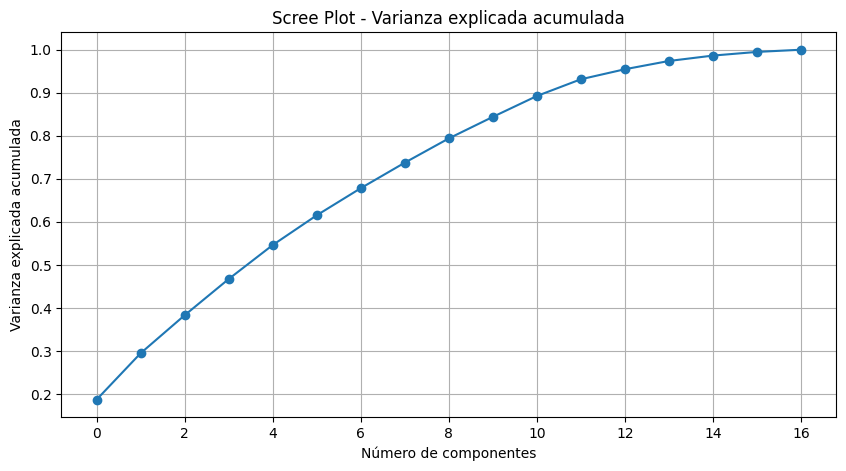

In [27]:
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca_temp.explained_variance_ratio_), marker='o')
plt.title("Scree Plot - Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

A partir del análisis del vector de varianza explicada y del Scree Plot, se observa que los primeros 10 componentes principales explican aproximadamente el 84.39% de la variabilidad total del conjunto de datos. A partir del componente 11 el aporte marginal de varianza se vuelve pequeño, indicando que la curva comienza a aplanarse.

Por lo tanto, para el Caso 6 se seleccionaron los 10 componentes principales, logrando una reducción significativa de dimensionalidad sin perder información relevante.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separar X e y desde df_bal
X_bal = df_bal.drop("metodo", axis=1)
y_bal = df_bal["metodo"]

# 2. Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

# 3. PCA con 10 componentes
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# 4. Construir df_pca
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(10)])
df_pca["metodo"] = y_bal.values

# Revisar
df_pca.head(), df_pca.shape

(        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0 -2.319395 -0.223070  0.867958 -0.711490  2.102353 -2.116561 -0.748808   
 1 -1.207545  2.274958  0.892861  2.065344 -2.310965 -1.285370  0.039078   
 2 -1.784780  1.912466  0.021279  0.962747 -2.014968 -2.300568 -0.539933   
 3 -2.528266  1.175310 -0.204942  3.052607  0.339961  0.642792  0.203226   
 4 -2.948930  0.323420  1.574941  1.103797 -2.064988  1.152895 -0.074699   
 
         PC8       PC9      PC10  metodo  
 0  0.245249  0.911327 -0.465771       1  
 1  0.115015  0.741552  0.008863       1  
 2  0.078603  0.594048 -0.421149       1  
 3  0.849056 -1.863063  0.508989       1  
 4 -0.503720  1.270242 -0.635805       1  ,
 (1887, 11))

## IV. Aplicacion de regresión logistica para cada unos de los casos:





In [29]:
#Función general para entrenar la regresión logística

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def log_reg_accuracy(df, target="metodo", scale=True):
    # Separar X e y
    X = df.drop(columns=[target])
    y = df[target]

    # 70% entrenamiento, 30% prueba (estratificado por clase)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # Escalar solo si se indica
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Modelo de regresión logística multiclase
    modelo = LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        multi_class="multinomial"
    )

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predicciones
    y_pred = modelo.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    return acc

In [30]:
#Modelo con df_model (conjunto original transformado):

accuracy_df_model = log_reg_accuracy(df_model, target="metodo", scale=True)
print("Accuracy – Caso 1/4 (df_model, original transformado):", accuracy_df_model)

Accuracy – Caso 1/4 (df_model, original transformado): 0.5316742081447964


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


NOTA: Recordemos que no tenemos datos faltantes, atipicos, ni fuertemente relacionados por lo que pasamos a caso de los datos balanceados.

In [31]:
# Modelo con df_bal (conjunto balanceado con SMOTE):

accuracy_df_bal = log_reg_accuracy(df_bal, target="metodo", scale=True)
print("Accuracy – Caso 5 (df_bal, balanceado SMOTE):", accuracy_df_bal)

Accuracy – Caso 5 (df_bal, balanceado SMOTE): 0.564373897707231


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [32]:
# Modelo con df_pca (conjunto balanceado + PCA):

accuracy_df_pca = log_reg_accuracy(df_pca, target="metodo", scale=False)
print("Accuracy – Caso 6 (df_pca, balanceado + PCA):", accuracy_df_pca)

Accuracy – Caso 6 (df_pca, balanceado + PCA): 0.4708994708994709


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [33]:
# Tabla resumen de accuracies:

resultados = pd.DataFrame({
    "Caso": [
        "Conjunto original transformado (df_model)",
        "Conjunto balanceado sin PCA (df_bal)",
        "Conjunto balanceado + PCA (df_pca)"
    ],
    "Accuracy": [
        accuracy_df_model,
        accuracy_df_bal,
        accuracy_df_pca
    ]
})



In [34]:
tabla_final = resultados.set_index("Caso")
tabla_final

,Accuracy
Caso,
Conjunto original transformado (df_model),0.531674
Conjunto balanceado sin PCA (df_bal),0.564374
Conjunto balanceado + PCA (df_pca),0.470899


Al comparar los tres escenarios evaluados, se observa que el mejor desempeño corresponde al conjunto balanceado sin PCA, con un accuracy de 56.43%. El balanceo mediante SMOTE permitió reducir el sesgo hacia la clase mayoritaria y mejorar la capacidad predictiva del modelo.

El conjunto original transformado obtuvo un accuracy menor (53.17%), lo cual confirma que el desbalance inicial afectaba negativamente el aprendizaje del modelo.

Por otro lado, la aplicación de PCA redujo el rendimiento (47.09%). Aunque PCA conserva gran parte de la varianza, la transformación de las variables en componentes principales eliminó información específica relevante para la regresión logística. Por tanto, en este caso, PCA no fue beneficioso para el desempeño del modelo, ya que la reducción de dimensionalidad sacrificó precisión.

En conclusión, el modelo de regresión logística funciona mejor cuando se trabaja con el conjunto balanceado sin reducción de dimensionalidad.

## ANEXO

Realizamos un ajuste en la estrategia de balanceo con el fin de evaluar si un método diferente podría mejorar la accuracy del modelo; en este caso, se aplicó la técnica de undersampling.

In [35]:
#PASO 5: BALANCEO UTILIZANDO LA TECNICA DE undersampling

# 1. Variables que deben convertirse a dummies
vars_dummies = ["wife_edu", "husband_edu",
                "standard_of_living_index",
                "husband_occupation"]

df_model = pd.get_dummies(df, columns=vars_dummies, drop_first=True)

# 1.1 Aseguramos que las binarias sean numéricas (aunque aquí no hay SMOTE, igual es sano)
cols_binarias = ["wife_religion", "wife_working", "media_exposure"]
df_model[cols_binarias] = df_model[cols_binarias].astype(float)

# 2. Separar X e y
X = df_model.drop("metodo", axis=1)
y = df_model["metodo"]

# 3. Aplicar UNDERSAMPLING: todas las clases al mínimo (333)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)  # estrategia 'auto' → todas las clases al tamaño de la minoritaria
X_under, y_under = rus.fit_resample(X, y)

# 4. Reconstruir el dataframe balanceado por undersampling
df_bal_under = pd.concat(
    [pd.DataFrame(X_under, columns=X.columns),
     pd.DataFrame(y_under, columns=["metodo"])],
    axis=1
)

# 5. Verificar distribución de clases
print("Distribución de clases en df_bal_under:")
print(df_bal_under["metodo"].value_counts())

Distribución de clases en df_bal_under:
metodo
1    333
2    333
3    333
Name: count, dtype: int64


In [36]:
# Paso 6. Aplicamos PCA con el modelo anterior:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separar X e y
X_under_bal = df_bal_under.drop("metodo", axis=1)
y_under_bal = df_bal_under["metodo"]

# 2. Escalar
scaler_under = StandardScaler()
X_under_scaled = scaler_under.fit_transform(X_under_bal)

# 3. PCA completo
pca_under = PCA()
pca_under.fit(X_under_scaled)

PCA()

In [37]:
var_individual = pca_under.explained_variance_ratio_
var_individual

array([0.18953991, 0.10532216, 0.08929818, 0.08890496, 0.0819327 ,
       0.07045249, 0.06386519, 0.06327986, 0.05547684, 0.04878764,
       0.04497367, 0.0407011 , 0.02346629, 0.01923442, 0.00615765,
       0.00575526, 0.00285169])

In [38]:
var_acumulada = np.cumsum(var_individual)
var_acumulada

array([0.18953991, 0.29486206, 0.38416024, 0.4730652 , 0.5549979 ,
       0.62545039, 0.68931558, 0.75259544, 0.80807228, 0.85685993,
       0.90183359, 0.94253469, 0.96600098, 0.98523541, 0.99139305,
       0.99714831, 1.        ])

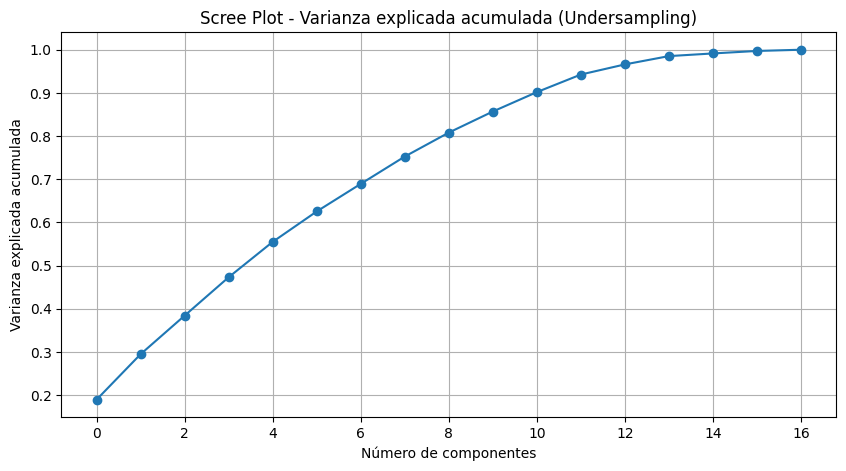

In [39]:
plt.figure(figsize=(10,5))
plt.plot(var_acumulada, marker='o')
plt.title("Scree Plot - Varianza explicada acumulada (Undersampling)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

In [40]:
#Eleccion de los componentes:

componentes_80 = np.argmax(var_acumulada >= 0.80) + 1
componentes_80

np.int64(9)

In [41]:
componentes_90 = np.argmax(var_acumulada >= 0.90) + 1
componentes_90

np.int64(11)

Elegiremos 10 componentes porque capturan el 85% de los datos

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separar X e y (undersampling)
X_under = df_bal_under.drop("metodo", axis=1)
y_under = df_bal_under["metodo"]

# 2. Escalado
scaler_under = StandardScaler()
X_under_scaled = scaler_under.fit_transform(X_under)

# 3. PCA con 10 componentes (los óptimos seleccionados)
pca_under_10 = PCA(n_components=10)
X_under_pca_10 = pca_under_10.fit_transform(X_under_scaled)

# 4. Crear df_pca_under (el definitivo con 10 PCs)
df_pca_under = pd.DataFrame(
    X_under_pca_10,
    columns=[f"PC{i+1}" for i in range(10)]
)

# Agregar la variable objetivo
df_pca_under["metodo"] = y_under.values

# Visualizar
print(df_pca_under.head())
print(df_pca_under.shape)

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.591295  1.250978 -0.261624  1.182986  1.937460 -1.775358  0.706093   
1  0.647178 -0.359929  1.279526  0.072154 -0.507739  0.925467  1.334785   
2 -0.075466 -0.844983  0.894996 -1.918741  2.006407  2.307914  0.717889   
3 -2.354047  0.642272  1.129495  0.588587 -1.408108  0.867908 -0.661571   
4  1.573763 -1.298455 -1.012159 -0.668157 -1.411167 -0.013319  0.688977   

        PC8       PC9      PC10  metodo  
0  0.056423  0.242727 -0.404852       1  
1  1.021098 -0.149594  0.598031       1  
2 -0.795172 -1.102038 -1.685069       1  
3 -1.702352  1.609725 -0.818160       1  
4 -0.096182  0.178110  0.018682       1  
(999, 11)


Calculemos el modelo de regresion logica para estos casos

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def log_reg_accuracy(df, target="metodo", scale=True):
    # Separar X e y
    X = df.drop(columns=[target])
    y = df[target]

    # 70% train, 30% test (estratificado)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # Escalado si aplica
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Modelo logística multiclase
    modelo = LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        multi_class="multinomial"
    )

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    return acc

In [44]:
accuracy_df_bal_under = log_reg_accuracy(
    df_bal_under,
    target="metodo",
    scale=True
)

print("Accuracy – df_bal_under (Undersampling sin PCA):", accuracy_df_bal_under)

Accuracy – df_bal_under (Undersampling sin PCA): 0.51


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [45]:
accuracy_df_pca_under = log_reg_accuracy(
    df_pca_under,
    target="metodo",
    scale=False
)

print("Accuracy – df_pca_under (Undersampling + PCA):", accuracy_df_pca_under)

Accuracy – df_pca_under (Undersampling + PCA): 0.44666666666666666


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [46]:
# Tabla resumen de accuracies (Balanceo_Undersampling):

resultados1 = pd.DataFrame({
    "Caso": [
        "Conjunto original transformado (df_model)",
        "Conjunto balanceado sin PCA (Balanceo Undersampling)",
        "Conjunto balanceado + PCA (Undersampling)"
    ],
    "Accuracy": [
        accuracy_df_model,
        accuracy_df_bal_under,
        accuracy_df_pca_under
    ]
})



In [47]:
tabla_final1 = resultados1.set_index("Caso")
tabla_final1

,Accuracy
Caso,
Conjunto original transformado (df_model),0.531674
Conjunto balanceado sin PCA (Balanceo Undersampling),0.510000
Conjunto balanceado + PCA (Undersampling),0.446667


En este caso, aunque sustituimos el balanceo mediante SMOTE por la técnica de undersampling, los resultados de accuracy obtenidos fueron inferiores a los alcanzados previamente con SMOTE. Por tanto, el mejor desempeño del modelo corresponde al proceso realizado con la técnica de sobremuestreo (SMOTE).